# Análisis de Costos de Equipos — Materias Primas y como se relacionan

Este notebook identifica que materias primas (X, Y, Z) explican el precio de cada equipo, valida el hallazgo con las pruebas estadísticas correspondientes, y proyecta el costo esperado con un intervalo de incertidumbre.

**Datos**: tres series de precios de materias primas (`X.csv`, `Y.csv`, `Z.csv`) y un archivo consolidado (`historico_equipos.csv`) con los precios de ambos equipos junto a las tres materias primas ya alineadas por fecha.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan, het_arch, linear_reset
from sklearn.metrics import r2_score
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import pmdarima as pm

# Rutass
# rutas de la bases de datos desde mi pc

ruta_x = "C:\\Users\\hp\\Desktop\\Prueba Tecnica Cientifico de Datos Senior\\Prueba tecnica Senior\\Datos\\X.csv"
ruta_y = "C:\\Users\\hp\\Desktop\\Prueba Tecnica Cientifico de Datos Senior\\Prueba tecnica Senior\\Datos\\Y.csv"
ruta_z = "C:\\Users\\hp\\Desktop\\Prueba Tecnica Cientifico de Datos Senior\\Prueba tecnica Senior\\Datos\\Z.csv"
ruta_historicos = "C:\\Users\\hp\\Desktop\\Prueba Tecnica Cientifico de Datos Senior\\Prueba tecnica Senior\\Datos\\historico_equipos.csv"

# X: separador estándar, fecha en formato ISO (año-mes-día)
datax = pd.read_csv(ruta_x, sep=',')
datax['Date'] = pd.to_datetime(datax['Date'])

# Y: separador ';', decimal ',', encodificacion con utf-8-sig
# fecha en formato día/mes (porque hay valores de día > 12 en la primera posición, entonces se deduce)
datay = pd.read_csv(ruta_y, sep=';', decimal=',', encoding='utf-8-sig')

datay['Date'] = pd.to_datetime(datay['Date'], dayfirst=True)

# Z: leerlo
dataz = pd.read_csv(ruta_z)
dataz['Date'] = pd.to_datetime(dataz['Date'])

# Consolidado lectura, estos son los historicos
datahistoricos = pd.read_csv(ruta_historicos)
datahistoricos['Date'] = pd.to_datetime(datahistoricos['Date'])

## Analisis de fechas de los datos

Antes de analizar nada, hay que confirmar qué es exactamente el archivo consolidado y si se puede confiar en él.
#### ¿Hay fechas que no aparecen en el consolidado?

In [6]:
rango_min, rango_max = datahistoricos['Date'].min(), datahistoricos['Date'].max()

x_rango = datax[(datax['Date'] >= rango_min) & (datax['Date'] <= rango_max)]
y_rango = datay[(datay['Date'] >= rango_min) & (datay['Date'] <= rango_max)]
z_rango = dataz[(dataz['Date'] >= rango_min) & (dataz['Date'] <= rango_max)]

faltantes_x = set(x_rango['Date']) - set(datahistoricos['Date'])
faltantes_y = set(y_rango['Date']) - set(datahistoricos['Date'])
faltantes_z = set(z_rango['Date']) - set(datahistoricos['Date'])

print("Fechas de X ausentes en el consolidado:", len(faltantes_x))
print("Fechas de Y ausentes en el consolidado:", len(faltantes_y))
print("Fechas de Z ausentes en el consolidado:", len(faltantes_z))

print("% de X ausente:", round(len(faltantes_x) / len(x_rango) * 100, 2), "%")
print("% de Y ausente:", round(len(faltantes_y) / len(y_rango) * 100, 2), "%")
print("% de Z ausente:", round(len(faltantes_z) / len(z_rango) * 100, 2), "%")

Fechas de X ausentes en el consolidado: 0
Fechas de Y ausentes en el consolidado: 37
Fechas de Z ausentes en el consolidado: 34
% de X ausente: 0.0 %
% de Y ausente: 1.04 %
% de Z ausente: 0.95 %



De acá en adelante se trabaja únicamente con `datahistoricos`, que ya contiene las 3 materias primas y los 2 equipos alineados. La moneda/unidad de los precios tampoco está especificada en los datos


## Exploración visual

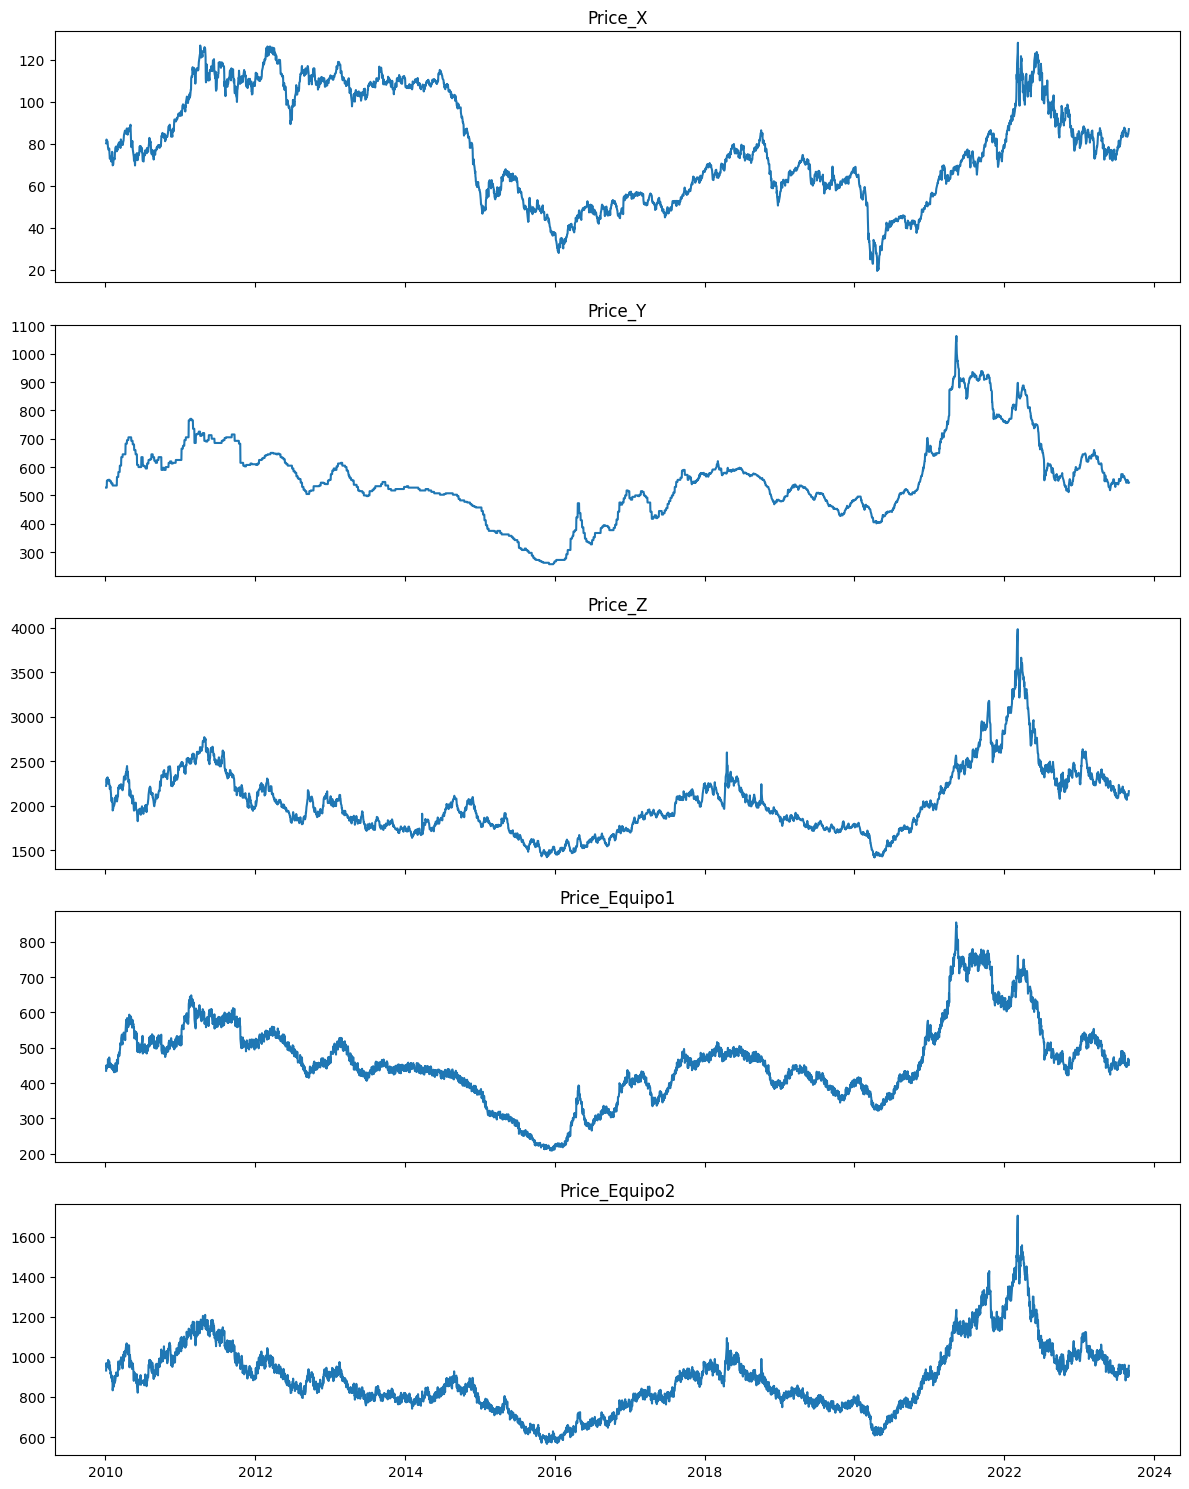

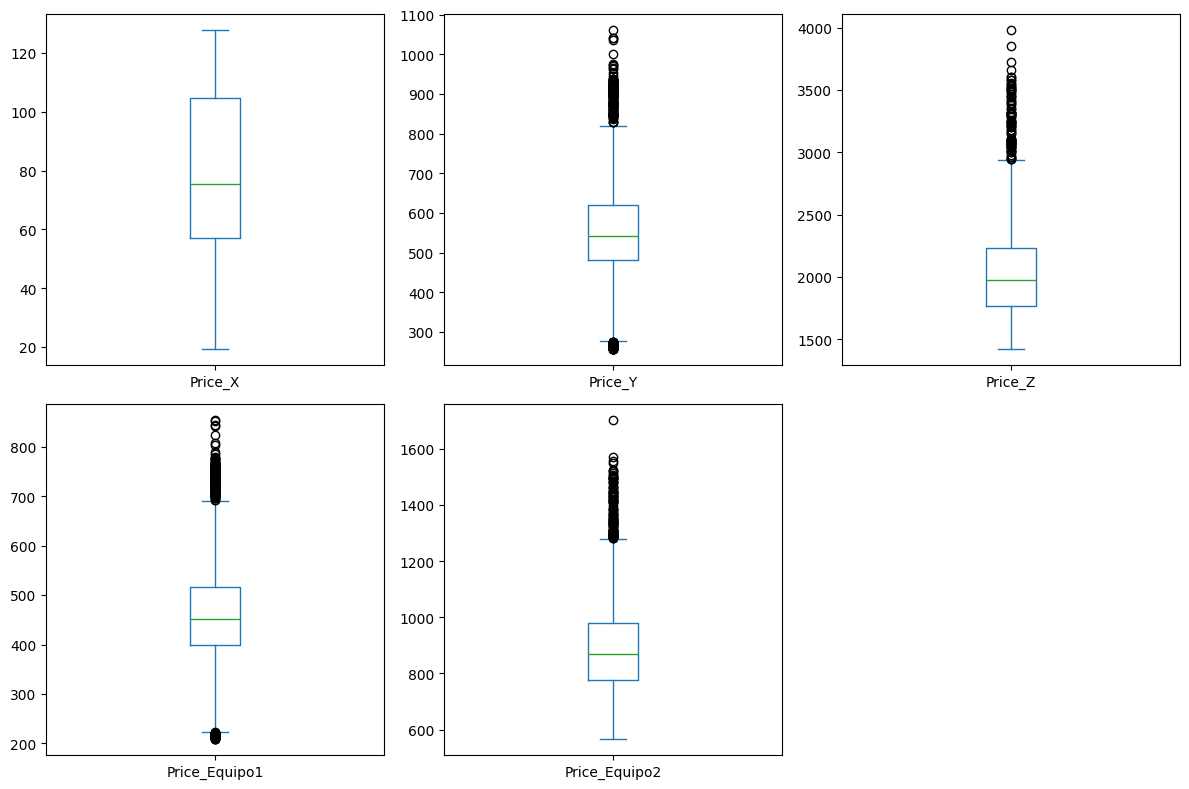

In [7]:
columnas = ['Price_X', 'Price_Y', 'Price_Z', 'Price_Equipo1', 'Price_Equipo2']

fig, axes = plt.subplots(5, 1, figsize=(12, 15), sharex=True)
for ax, col in zip(axes, columnas):
    ax.plot(datahistoricos['Date'], datahistoricos[col])
    ax.set_title(col)
plt.tight_layout()
plt.show()

datahistoricos[columnas].plot(kind='box', subplots=True, layout=(2, 3), figsize=(12, 8))
plt.tight_layout()
plt.show()

**Interpretación**: las cinco series comparten la misma forma en general, teniendo un valle muy marcado entre 2015-2016, un pico agudo en 2021-2022 (coincide con tiempo de post-pandemia). Ese comovimiento hace sospechar tendencia compartida más que ver una  relación directa entre variables, tendriamos que confirmarlo con un test formal, no alcanza con mirar solo los graficos.

## Prueba de hipotesis de Estacionariedad

- **H0**: la serie tiene raíz unitaria, entonces no es estacionaria.
- **H1**: la serie no tiene raíz unitaria, es estacionaria.

In [8]:
# ADF sobre los precios tal cual vienen 
for col in columnas:
    resultado = adfuller(datahistoricos[col])
    print(col, "- p-valor:", resultado[1])


print(datahistoricos[['Price_X', 'Price_Y', 'Price_Z']].corr())


Price_X - p-valor: 0.4284384758660065
Price_Y - p-valor: 0.10831944549020922
Price_Z - p-valor: 0.2051913105544712
Price_Equipo1 - p-valor: 0.14449794751086525
Price_Equipo2 - p-valor: 0.329036684289739
          Price_X   Price_Y   Price_Z
Price_X  1.000000  0.491650  0.475738
Price_Y  0.491650  1.000000  0.844196
Price_Z  0.475738  0.844196  1.000000


Las cinco series salen no estacionarias en sus niveles. Confirma la sospecha que vimos en la grafica, Hay que transformar a retornos (% de cambio día a día).

In [9]:
retornos = datahistoricos[columnas].pct_change().dropna() 

for col in retornos.columns:
    resultado = adfuller(retornos[col])
    print(col, "- p-valor:", resultado[1])

print(retornos[['Price_X', 'Price_Y', 'Price_Z']].corr())

Price_X - p-valor: 0.0
Price_Y - p-valor: 1.8655018392418526e-17
Price_Z - p-valor: 0.0
Price_Equipo1 - p-valor: 1.2321928439959555e-26
Price_Equipo2 - p-valor: 0.0
          Price_X   Price_Y   Price_Z
Price_X  1.000000  0.020477  0.174296
Price_Y  0.020477  1.000000  0.093492
Price_Z  0.174296  0.093492  1.000000


Sobre retornos, las cinco series sí son estacionarias. Y la correlación entre materias primas bajó fuerte respecto a niveles (YconZ pasó de 0.84 a 0.09) — confirma que buena parte de esa correlación en niveles era tendencia compartida, no relación real entre los insumos. De acá trabajarmos siempre sobre sus `retornos`, no sobre los precios originales.

## Identificación de Covariables predictoras


Correlación de cada materia prima con cada equipo, ya en retornos.

In [10]:


corr = retornos[['Price_X', 'Price_Y', 'Price_Z',
                 'Price_Equipo1', 'Price_Equipo2']].corr().round(2)


corr = corr.mask(np.triu(np.ones(corr.shape), k=1).astype(bool))

display(corr)

,Price_X,Price_Y,Price_Z,Price_Equipo1,Price_Equipo2
Price_X,1.00,NaN,NaN,NaN,NaN
Price_Y,0.02,1.00,NaN,NaN,NaN
Price_Z,0.17,0.09,1.00,NaN,NaN
Price_Equipo1,0.03,0.38,0.02,1.00,NaN
Price_Equipo2,0.07,0.10,0.40,0.05,1.0


**Hallazgo**:Vemos claramente que Y se asocia con Equipo1 con valor de 0.38, Z se asocia con Equipo2 con 0.4 — mucho más fuerte que las otras combinaciones. Falta confirmar si controlando las tres materias primas a la vez (regresión múltiple) que nos muestra, para descartar que sea solo por la correlación entre las materias primas entre sí.

ajustando los modelos tenemos que el modelo general para los equipos

$$
PriceEquipo_i = \beta_0 + \beta_1PriceX + \beta_2PriceY + \beta_3PriceZ + E
\ , \ con \ i=1 , 2
$$


In [11]:
n = len(retornos)
corte = int(n * 0.8)
train = retornos.iloc[:corte]
test = retornos.iloc[corte:]

X_train_full = sm.add_constant(train[['Price_X', 'Price_Y', 'Price_Z']])
X_test_full = sm.add_constant(test[['Price_X', 'Price_Y', 'Price_Z']])

modelo_full = sm.OLS(train['Price_Equipo1'], X_train_full).fit()

pred = modelo_full.predict(X_test_full)

residuos = test['Price_Equipo1'] - pred

print(modelo_full.summary())
print("R² fuera de muestra:", r2_score(test['Price_Equipo1'], pred)*100, "%")
print("Durbin-Watson (residuos de test):", durbin_watson(residuos).round(2))

                            OLS Regression Results                            
Dep. Variable:          Price_Equipo1   R-squared:                       0.125
Model:                            OLS   Adj. R-squared:                  0.124
Method:                 Least Squares   F-statistic:                     133.6
Date:                Wed, 05 Aug 2026   Prob (F-statistic):           6.08e-81
Time:                        16:12:06   Log-Likelihood:                 6439.0
No. Observations:                2823   AIC:                        -1.287e+04
Df Residuals:                    2819   BIC:                        -1.285e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0003      0.000      0.633      0.5

Asi quedaria nuestro modelo ajustado

$$
\widehat{Price\_Equipo1}
=
0.0003
+
0.0194\,PriceX
+
0.9532\,PriceY
+
0.0074\,PriceZ
$$

In [12]:
modelo_full = sm.OLS(train['Price_Equipo2'], X_train_full).fit()

pred = modelo_full.predict(X_test_full)

residuos = test['Price_Equipo2'] - pred

print(modelo_full.summary())
print("R² fuera de muestra:", r2_score(test['Price_Equipo2'], pred))
print("Durbin-Watson (residuos de test):", durbin_watson(residuos))

                            OLS Regression Results                            
Dep. Variable:          Price_Equipo2   R-squared:                       0.137
Model:                            OLS   Adj. R-squared:                  0.136
Method:                 Least Squares   F-statistic:                     149.5
Date:                Wed, 05 Aug 2026   Prob (F-statistic):           6.23e-90
Time:                        16:12:06   Log-Likelihood:                 6440.1
No. Observations:                2823   AIC:                        -1.287e+04
Df Residuals:                    2819   BIC:                        -1.285e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0003      0.000      0.630      0.5

Asi quedaria el modelo ajustado para el equipo 2

$$
\widehat{Price\_Equipo2}
=
0.0003
-
0.0071\,PriceX
+
0.1298\,PriceY
+
0.7744\,PriceZ
$$

Los p-valores confirman el hallazgo de la correlación: en Equipo1 solo Y es significativa (X y Z no aportan significativamente). En Equipo2, Y y Z son significativas, X no. El Durbin-Watson (~2.9,2.8-3.0) muestra algo de autocorrelación negativa en los residuos 

Se simplifican los modelos a solo las variables significativas.

In [13]:
X_train_eq1 = sm.add_constant(train[['Price_Y']])
X_test_eq1 = sm.add_constant(test[['Price_Y']])
modelo_eq1_simple = sm.OLS(train['Price_Equipo1'], X_train_eq1).fit()
pred_eq1_simple = modelo_eq1_simple.predict(X_test_eq1)

X_train_eq2 = sm.add_constant(train[['Price_Y', 'Price_Z']])
X_test_eq2 = sm.add_constant(test[['Price_Y', 'Price_Z']])
modelo_eq2_simple = sm.OLS(train['Price_Equipo2'], X_train_eq2).fit()
pred_eq2_simple = modelo_eq2_simple.predict(X_test_eq2)

print("Equipo1 (con Y) - R² fuera de muestra:", r2_score(test['Price_Equipo1'], pred_eq1_simple))
print("Equipo2 (con Y and Z) - R² fuera de muestra:", r2_score(test['Price_Equipo2'], pred_eq2_simple))

Equipo1 (con Y) - R² fuera de muestra: 0.21340209606180593
Equipo2 (con Y and Z) - R² fuera de muestra: 0.24137188185553615


El R² no cambia prácticamente nada al sacar X — confirma que no aportaba señal real, solo ruido. Modelos finales:

$$
Price\_Equipo1 = f(Price\_Y)
$$

$$
Price\_Equipo2 = f(Price\_Y,\;Price\_Z)
$$

## Ventanas y particion


¿El hallazgo se sostiene en distintas ventanas de tiempo y distintas particiones train/test, o depende de una elección arbitraria de corte?

In [14]:
# Estabilidad del coeficiente entre la primera y segunda mitad del histórico de train
mitad = len(train) // 2
for nombre, sub in [("Primera mitad", train.iloc[:mitad]), ("Segunda mitad", train.iloc[mitad:])]:
    m1 = sm.OLS(sub['Price_Equipo1'], sm.add_constant(sub[['Price_Y']])).fit()
    m2 = sm.OLS(sub['Price_Equipo2'], sm.add_constant(sub[['Price_Y', 'Price_Z']])).fit()
    print(f"{nombre}: Equipo1 coef Y={m1.params['Price_Y']:.3f} | "
          f"Equipo2 coef Y={m2.params['Price_Y']:.3f}, coef Z={m2.params['Price_Z']:.3f}")

print()

# R² fuera de muestra con distintos splits train/test
for ratio in [0.7, 0.75, 0.8, 0.85, 0.9]:
    corte_r = int(len(retornos) * ratio)
    tr, te = retornos.iloc[:corte_r], retornos.iloc[corte_r:]
    m1 = sm.OLS(tr['Price_Equipo1'], sm.add_constant(tr[['Price_Y']])).fit()
    m2 = sm.OLS(tr['Price_Equipo2'], sm.add_constant(tr[['Price_Y', 'Price_Z']])).fit()
    r2_1 = r2_score(te['Price_Equipo1'], m1.predict(sm.add_constant(te[['Price_Y']])))
    r2_2 = r2_score(te['Price_Equipo2'], m2.predict(sm.add_constant(te[['Price_Y', 'Price_Z']])))
    print(f"Split {int(ratio*100)}/{int((1-ratio)*100)}: R² Equipo1={r2_1:.3f} | R² Equipo2={r2_2:.3f}")

Primera mitad: Equipo1 coef Y=0.965 | Equipo2 coef Y=0.148, coef Z=0.695
Segunda mitad: Equipo1 coef Y=0.946 | Equipo2 coef Y=0.118, coef Z=0.874

Split 70/30: R² Equipo1=0.172 | R² Equipo2=0.192
Split 75/25: R² Equipo1=0.190 | R² Equipo2=0.219
Split 80/19: R² Equipo1=0.213 | R² Equipo2=0.241
Split 85/15: R² Equipo1=0.170 | R² Equipo2=0.275
Split 90/9: R² Equipo1=0.185 | R² Equipo2=0.211


Antes de confiar en el resultado, verifiqué que no fuera casualidad de una sola partición de los datos: probé cinco cortes distintos de entrenamiento/prueba (70/30 hasta 90/10) y el desempeño se mantuvo estable en un rango razonable (R² entre 0.17 y 0.21 en Equipo1, entre 0.19 y 0.28 en Equipo2), sin desplomarse en ninguno. También chequeé si la relación cambiaba con el tiempo, comparando los coeficientes entre la primera y la segunda mitad del histórico: para Equipo1 se mantuvo prácticamente igual (0.965 y 0.946), lo que confirma una relación estable con Y; para Equipo2, en cambio, el peso de Z creció de 0.70 a 0.87 entre ambos períodos, un hallazgo que documento como limitación del modelo en lugar de ignorarlo.

## Supuestos del error de la regresión

**Breusch-Pagan** — ¿la varianza del error depende del *valor* de Y/Z ese día?

In [15]:
print("--- Breusch-Pagan (homocedasticidad vs. regresores) ---")
bp_eq1 = het_breuschpagan(modelo_eq1_simple.resid, X_train_eq1)
bp_eq2 = het_breuschpagan(modelo_eq2_simple.resid, X_train_eq2)
print("Equipo1 - p-valor:", round(bp_eq1[1], 5))
print("Equipo2 - p-valor:", round(bp_eq2[1], 5))

--- Breusch-Pagan (homocedasticidad vs. regresores) ---
Equipo1 - p-valor: 0.65307
Equipo2 - p-valor: 0.17878


**ARCH-LM** — ¿la varianza del error depende del *momento en el tiempo* (independiente del valor de Y/Z)?

In [16]:
print("--- ARCH-LM (homocedasticidad en el tiempo) ---")
arch_eq1 = het_arch(modelo_eq1_simple.resid)
arch_eq2 = het_arch(modelo_eq2_simple.resid)
print("Equipo1 - p-valor:", round(arch_eq1[1], 5))
print("Equipo2 - p-valor:", round(arch_eq2[1], 5))

--- ARCH-LM (homocedasticidad en el tiempo) ---
Equipo1 - p-valor: 0.0
Equipo2 - p-valor: 0.0


**HAC (Newey-West)** — corrige el error estándar (no los coeficientes) para que sea válido incluso con la heterocedasticidad en el tiempo y la autocorrelación ya detectadas. `maxlags=5` le dice cuántos días atrás mirar al estimar cómo se correlacionan los residuos.

In [17]:
modelo_eq1_robusto = sm.OLS(train['Price_Equipo1'], X_train_eq1).fit(cov_type='HAC', cov_kwds={'maxlags': 5})
print(modelo_eq1_robusto.summary())

                            OLS Regression Results                            
Dep. Variable:          Price_Equipo1   R-squared:                       0.124
Model:                            OLS   Adj. R-squared:                  0.124
Method:                 Least Squares   F-statistic:                     428.0
Date:                Wed, 05 Aug 2026   Prob (F-statistic):           1.21e-88
Time:                        16:12:06   Log-Likelihood:                 6438.5
No. Observations:                2823   AIC:                        -1.287e+04
Df Residuals:                    2821   BIC:                        -1.286e+04
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0003      0.000      1.543      0.1

In [18]:
modelo_eq2_robusto = sm.OLS(train['Price_Equipo2'], X_train_eq2).fit(cov_type='HAC', cov_kwds={'maxlags': 5})
print(modelo_eq2_robusto.summary())

                            OLS Regression Results                            
Dep. Variable:          Price_Equipo2   R-squared:                       0.137
Model:                            OLS   Adj. R-squared:                  0.137
Method:                 Least Squares   F-statistic:                     152.0
Date:                Wed, 05 Aug 2026   Prob (F-statistic):           2.09e-63
Time:                        16:12:06   Log-Likelihood:                 6440.1
No. Observations:                2823   AIC:                        -1.287e+04
Df Residuals:                    2820   BIC:                        -1.286e+04
Df Model:                           2                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0003      0.000      1.550      0.1

**Residuos vs. ajustados** — chequeo visual de linealidad y homocedasticidad juntas

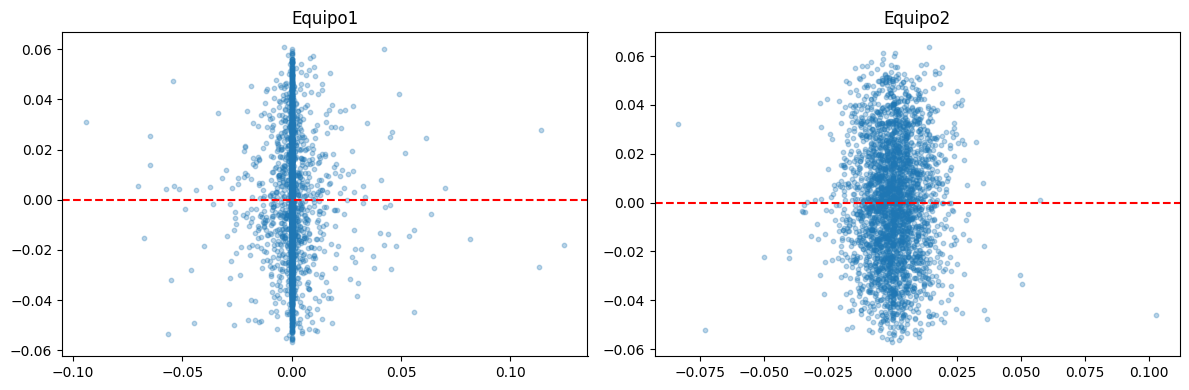

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(modelo_eq1_simple.fittedvalues, modelo_eq1_simple.resid, alpha=0.3, s=10)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Equipo1')
axes[1].scatter(modelo_eq2_simple.fittedvalues, modelo_eq2_simple.resid, alpha=0.3, s=10)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Equipo2')
plt.tight_layout()
plt.show()

**RESET** — versión formal de linealidad: ¿agregar términos no lineales (Y², Z²) mejoraría el modelo de forma significativa?

In [20]:
print("--- RESET (linealidad) ---")
reset_eq1 = linear_reset(modelo_eq1_simple, power=2, use_f=True)
reset_eq2 = linear_reset(modelo_eq2_simple, power=2, use_f=True)
print("Equipo1 - p-valor:", round(reset_eq1.pvalue, 5))
print("Equipo2 - p-valor:", round(reset_eq2.pvalue, 5))

--- RESET (linealidad) ---
Equipo1 - p-valor: 0.56913
Equipo2 - p-valor: 0.07628


**Resumen de los 4 supuestos clásicos**:

| Supuesto | Resultado |
|---|---|
| Independencia | Autocorrelación negativa leve (Durbin-Watson), corregido con HAC |
| Normalidad | No se cumple con el test Jarque-Bera, pero con el  n≈2823 no compromete la inferencia práctica |
| Homocedasticidad vs regresores | Hay homocedasticidad, p=0.65, p=0.18 (Breusch-Pagan) |
| Homocedasticidad en el tiempo |  p=0.0 significa que sí hay efectos ARCH (se rechaza el supuesto de homocedasticidad en el tiempo) clusters de volatilidad esperables, corregido con HAC |
| Linealidad | El modelo está bien especificado (RESET), sin patrón en el gráfico de residuos |

Los coeficientes centrales (Y y Z) se mantienen prácticamente iguales bajo errores estándar robustos — esto nos dice que aguanta el chequeo más exigente.

## Alternativas evaluadas y no adoptadas

Antes de la proyección final, se probaron alternativas mas complejas  para ver si superaban al modelo simple. Se documentan los resultados; el código de detalle no se mantiene en este notebook para no saturarlo innecesariamente:

- **Corrección AR(1) sobre los residuos**: con el residuo real del día anterior, el R² subía de ~0.21 a ~0.39 — pero al evaluarlo "a ciegas" (sin ese dato real, como sería en una proyección genuina a varios meses) el R² volvía a ~0.21. La mejora era producto de una fuga de información, no de una mejora real del modelo. No se adopta.
- **SARIMAX (auto_arima) con X, Y, Z como exógenas**: R² prácticamente idéntico al modelo simple (0.215 vs 0.214 en Equipo1), No justificaba hacerlo con complejidad extra.
- **Holt-Winters / descomposición estacional** sobre Y y Z: fuerza de estacionalidad de 0.04-0.05 (prácticamente era ruido) lo ddescarta, no hay estacionalidad de calendario real que aprovechar.
- **Simulación Monte Carlo** para propagar la incertidumbre de Y/Z hacia los equipos (bootstrap de retornos y residuos, compuesto día a día): metodológicamente más completa —permite responder preguntas condicionales tipo "¿qué pasa si Y sube fuerte?"—, pero se optó por el método analítico más simple (ver sección de Proyección) por una relación entre ambos: la varianza de los retornos del equipo ya contiene, por construcción, tanto lo que explican Y/Z como lo no explicado, dando un resultado equivalente sin el paso de simulación. Queda como mejora futura propuesto

## Proyección de costos

Ninguna serie es estacionaria en niveles, y el drift (tendencia promedio) resultó inestable entre distintas ventanas de tiempo — cambia de signo según cuántos meses se miren hacia atrás. Se descarta modelar una tendencia y se proyecta como **camino aleatorio sin drift**: el mejor pronóstico puntual es el último valor conocido, con una banda de incertidumbre que crece con la raíz cuadrada del horizonte.

Antes de asumir camino aleatorio, podemos mirar si Y y Z tienen estructura propia en su pasado que un modelo que se podría aprovechar mas. 

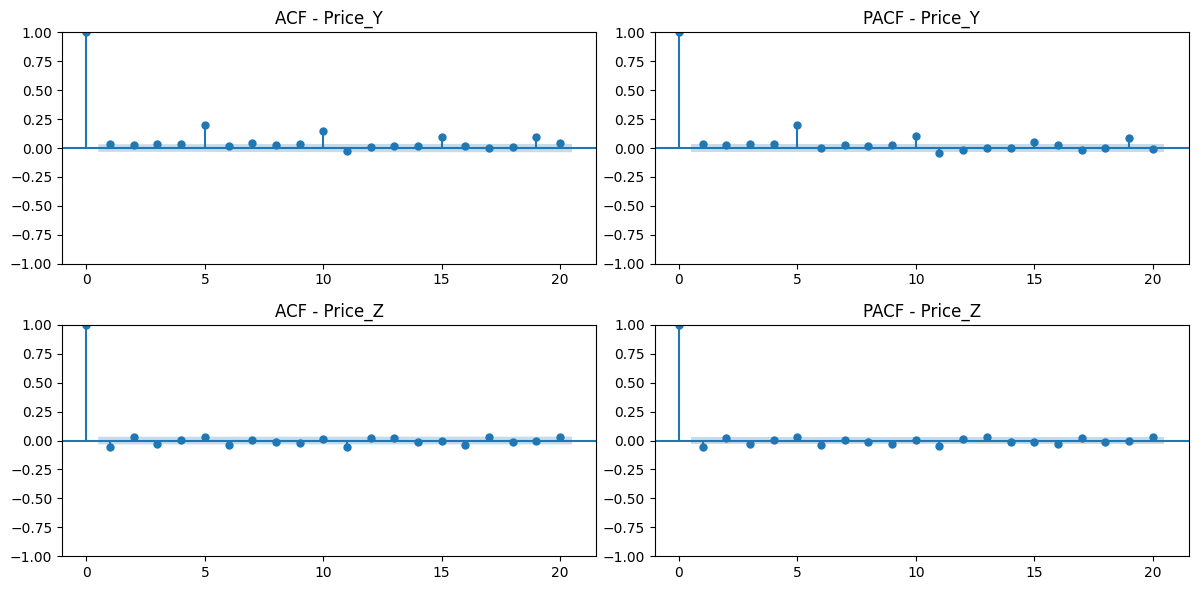

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
for i, col in enumerate(['Price_Y', 'Price_Z']):
    plot_acf(retornos[col], lags=20, ax=axes[i, 0], title=f'ACF - {col}')
    plot_pacf(retornos[col], lags=20, ax=axes[i, 1], title=f'PACF - {col}')
plt.tight_layout()
plt.show()

En Y, el lag 5 se nota claro se sale bien de la banda en las dos gráficas, y coincide con una semana (5 días hábiles). Los ecos en 10, 15 y 19 son mucho más débiles, casi al límite no prueban nada por sí solos, pero la forma decreciente da otra pista de que hay algo semanal ahí, no solo ruido. Z no muestra nada raro. Igual esto es solo una primera pista visual

In [22]:
n_dh = len(datahistoricos)
corte_dh = int(n_dh * 0.8)
train_dh = datahistoricos.iloc[:corte_dh]
test_dh = datahistoricos.iloc[corte_dh:]

horizonte_dias = 6 * 21  # 6 meses


train_y = train_dh['Price_Y']
test_y = test_dh['Price_Y'].iloc[:horizonte_dias]
pred_rw_y = np.full(len(test_y), train_y.iloc[-1])
modelo_arima_y = pm.auto_arima(train_y, seasonal=False, max_p=3, max_q=3, suppress_warnings=True)
pred_arima_y = modelo_arima_y.predict(n_periods=len(test_y))
train_z = train_dh['Price_Z']
test_z = test_dh['Price_Z'].iloc[:horizonte_dias]
pred_rw_z = np.full(len(test_z), train_z.iloc[-1])
modelo_arima_z = pm.auto_arima(train_z, seasonal=False, max_p=3, max_q=3, suppress_warnings=True)
pred_arima_z = modelo_arima_z.predict(n_periods=len(test_z))



In [23]:

rmse_rw_y = np.sqrt(((test_y - pred_rw_y) ** 2).mean())
rmse_arima_y = np.sqrt(((test_y - pred_arima_y) ** 2).mean())
print("Y - Random Walk RMSE:", round(rmse_rw_y, 2))
print("Y - ARIMA RMSE:", round(rmse_arima_y, 2))
rmse_rw_z = np.sqrt(((test_z - pred_rw_z) ** 2).mean())
rmse_arima_z = np.sqrt(((test_z - pred_arima_z) ** 2).mean())
print("Z - Random Walk RMSE:", round(rmse_rw_z, 2))
print("Z - ARIMA RMSE:", round(rmse_arima_z, 2))

Y - Random Walk RMSE: 189.88
Y - ARIMA RMSE: 162.92
Z - Random Walk RMSE: 251.54
Z - ARIMA RMSE: 250.94


- Y: RMSE baja de 189.88 con el random walk a 162.92 (ARIMA), casi 27 unidades menos de error promedio, mas o menos 14% de mejora. lo que confirma por el patrón semanal del ACF/PACF.
- Z: 251.54 vs 250.94 menos de 1 unidad de diferencia. Confirma que ahí no hay nada que un modelo más complejo pueda ayudar

In [24]:
print("Ventana de test (6 meses):", test_dh['Date'].iloc[0].date(), "a", test_dh['Date'].iloc[horizonte_dias-1].date())

Ventana de test (6 meses): 2020-12-08 a 2021-06-04


- Para Z, el random walk fue tan bueno como el ARIMA (R² prácticamente igual), nos quedamos queda con random walk. 
- Para Y un ARIMA(3,1,3) mejoró de forma real (consistente con el patrón semanal que Y mostraba en su propio ACF/PACF, a diferencia de X y Z). Se documenta como mejora futura y se mantiene random walk para ambas series, por simplicidad y consistencia del método.

In [25]:
horizonte = 6  # meses es el horizonte definido para el proyecto

ultimo_Y = datahistoricos['Price_Y'].iloc[-1]
ultimo_Z = datahistoricos['Price_Z'].iloc[-1]
ultimo_eq1 = datahistoricos['Price_Equipo1'].iloc[-1]
ultimo_eq2 = datahistoricos['Price_Equipo2'].iloc[-1]

vol_Y = retornos['Price_Y'].std()
vol_Z = retornos['Price_Z'].std()
vol_eq1 = retornos['Price_Equipo1'].std()
vol_eq2 = retornos['Price_Equipo2'].std()

dias_por_mes = 21
proyeccion = []
for m in range(1, horizonte + 1):
    dias = m * dias_por_mes
    banda_Y = ultimo_Y * vol_Y * np.sqrt(dias)
    banda_Z = ultimo_Z * vol_Z * np.sqrt(dias)
    banda_eq1 = ultimo_eq1 * vol_eq1 * np.sqrt(dias)
    banda_eq2 = ultimo_eq2 * vol_eq2 * np.sqrt(dias)

    proyeccion.append({
        'mes': m,
        'Y_esperado': ultimo_Y, 'Y_lo': ultimo_Y - 1.96*banda_Y, 'Y_hi': ultimo_Y + 1.96*banda_Y,
        'Z_esperado': ultimo_Z, 'Z_lo': ultimo_Z - 1.96*banda_Z, 'Z_hi': ultimo_Z + 1.96*banda_Z,
        'Equipo1_esperado': ultimo_eq1, 'Equipo1_lo': ultimo_eq1 - 1.96*banda_eq1, 'Equipo1_hi': ultimo_eq1 + 1.96*banda_eq1,
        'Equipo2_esperado': ultimo_eq2, 'Equipo2_lo': ultimo_eq2 - 1.96*banda_eq2, 'Equipo2_hi': ultimo_eq2 + 1.96*banda_eq2,
    })

proyeccion_df = pd.DataFrame(proyeccion)
print(proyeccion_df)

   mes  Y_esperado        Y_lo        Y_hi  Z_esperado         Z_lo  \
0    1       545.0  493.785956  596.214044     2165.25  1897.995453   
1    2       545.0  472.572404  617.427596     2165.25  1787.294996   
2    3       545.0  456.294673  633.705327     2165.25  1702.351547   
3    4       545.0  442.571912  647.428088     2165.25  1630.740907   
4    5       545.0  430.481916  659.518084     2165.25  1567.650666   
5    6       545.0  419.551724  670.448276     2165.25  1510.612729   

          Z_hi  Equipo1_esperado  Equipo1_lo  Equipo1_hi  Equipo2_esperado  \
0  2432.504547            451.73  343.972353  559.487647            955.35   
1  2543.205004            451.73  299.337674  604.122326            955.35   
2  2628.148453            451.73  265.088281  638.371719            955.35   
3  2699.759093            451.73  236.214706  667.245294            955.35   
4  2762.849334            451.73  210.776576  692.683424            955.35   
5  2819.887271            451.73  

**¿Hasta qué mes el rango sigue siendo útil?** Ancho del intervalo como % del valor esperado, mes a mes.

In [26]:
proyeccion_df['Y_ancho_pct'] = (proyeccion_df['Y_hi'] - proyeccion_df['Y_lo']) / proyeccion_df['Y_esperado'] * 100
proyeccion_df['Z_ancho_pct'] = (proyeccion_df['Z_hi'] - proyeccion_df['Z_lo']) / proyeccion_df['Z_esperado'] * 100
proyeccion_df['Equipo1_ancho_pct'] = (proyeccion_df['Equipo1_hi'] - proyeccion_df['Equipo1_lo']) / proyeccion_df['Equipo1_esperado'] * 100
proyeccion_df['Equipo2_ancho_pct'] = (proyeccion_df['Equipo2_hi'] - proyeccion_df['Equipo2_lo']) / proyeccion_df['Equipo2_esperado'] * 100

print(proyeccion_df[['mes', 'Y_ancho_pct', 'Z_ancho_pct', 'Equipo1_ancho_pct', 'Equipo2_ancho_pct']].round(1))

   mes  Y_ancho_pct  Z_ancho_pct  Equipo1_ancho_pct  Equipo2_ancho_pct
0    1         18.8         24.7               47.7               48.4
1    2         26.6         34.9               67.5               68.5
2    3         32.6         42.8               82.6               83.9
3    4         37.6         49.4               95.4               96.9
4    5         42.0         55.2              106.7              108.3
5    6         46.0         60.5              116.9              118.7


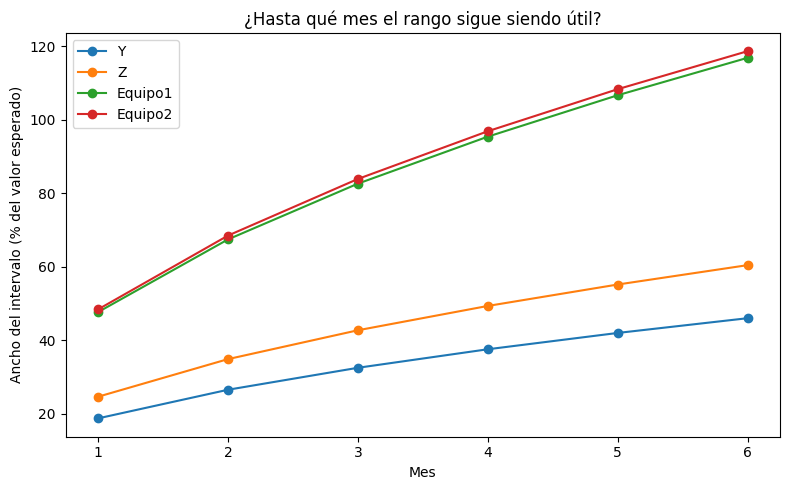

In [27]:
plt.figure(figsize=(8, 5))
plt.plot(proyeccion_df['mes'], proyeccion_df['Y_ancho_pct'], marker='o', label='Y')
plt.plot(proyeccion_df['mes'], proyeccion_df['Z_ancho_pct'], marker='o', label='Z')
plt.plot(proyeccion_df['mes'], proyeccion_df['Equipo1_ancho_pct'], marker='o', label='Equipo1')
plt.plot(proyeccion_df['mes'], proyeccion_df['Equipo2_ancho_pct'], marker='o', label='Equipo2')
plt.xlabel('Mes')
plt.ylabel('Ancho del intervalo (% del valor esperado)')
plt.title('¿Hasta qué mes el rango sigue siendo útil?')
plt.legend()
plt.tight_layout()
plt.show()

En Equipo1 y Equipo2, el ancho del intervalo supera el 100% del valor esperado a partir del mes 5 ,el rango pasa a ser más ancho que el propio precio central, momento en que empieza a perder utilidad para presupuestar. El mes 4 es el último donde se mantiene por debajo de ese umbral (95.4% y 96.9%). Con esto se propone un horizonte de proyección de **4 meses**, en vez de los 6 usados como punto de partida.

**¿Por qué la banda usa la varianza total y no solo la del residuo?** La varianza de los retornos de un equipo ya es, por construcción, la suma de lo que explica el insumo más lo que no explica (`Var(Equipo) = β² · Var(insumo) + Var(residuo)`) — por eso usar la volatilidad total del equipo ya es más conservador que usar solo el residuo. Falta chequear si además hace falta sumar el margen por no conocer el coeficiente β con certeza total (algo real en teoría, pero que con este tamaño de muestra suele ser marginal):

In [28]:
se_beta_Y = modelo_eq1_simple.bse['Price_Y']
var_residuos = modelo_eq1_simple.resid.var()
var_beta_tipico = (se_beta_Y * retornos['Price_Y'].std()) ** 2

print("Varianza de los residuos:", round(var_residuos, 8))
print("Aporte aproximado de la incertidumbre del coeficiente:", round(var_beta_tipico, 8))
print("Relación (segundo / primero):", round(var_beta_tipico / var_residuos, 4))

Varianza de los residuos: 0.00061188
Aporte aproximado de la incertidumbre del coeficiente: 2.5e-07
Relación (segundo / primero): 0.0004


La relación da 0.0004 (0.04%) — el margen por incertidumbre del coeficiente es real en la teoría, pero acá despreciable frente a la variabilidad propia de los datos, dado el tamaño de muestra (2823 observaciones). Confirma que la banda usada (volatilidad total del equipo) ya captura la incertidumbre relevante sin necesitar ese término extra.

Gráfico final: histórico reciente + proyección con banda, para las 4 series.

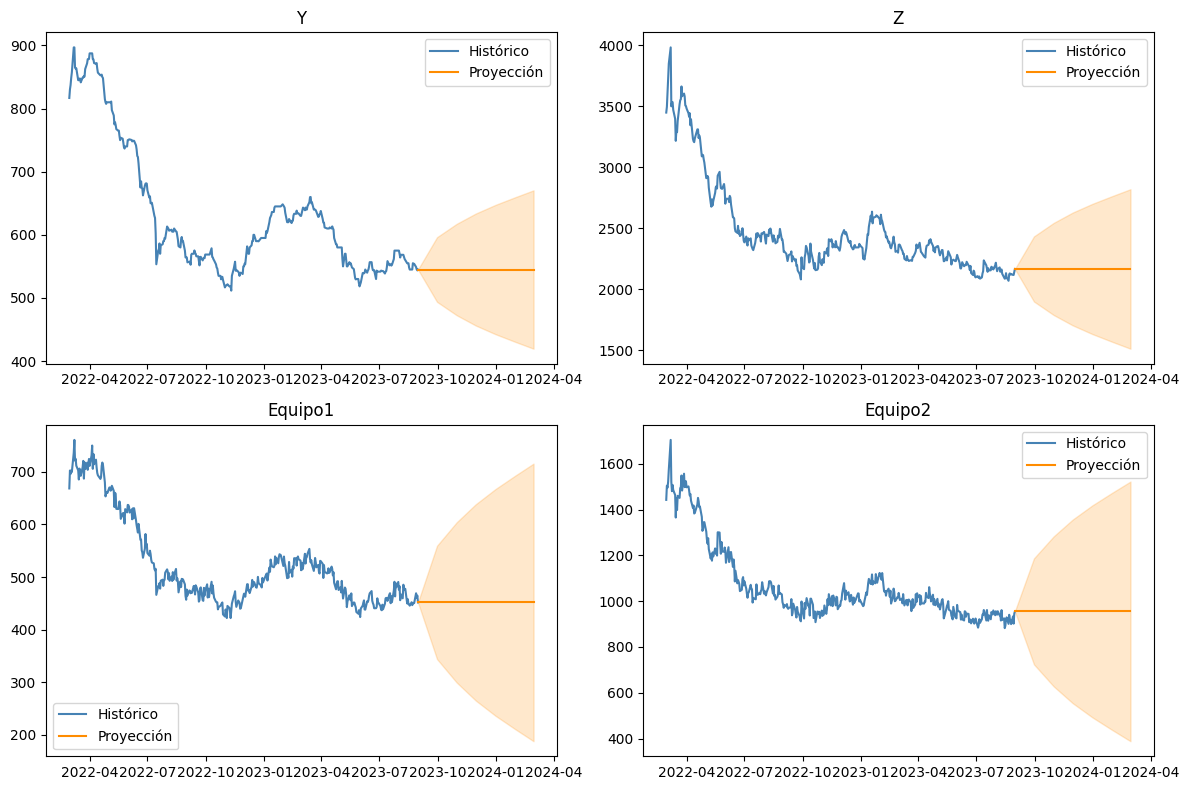

In [29]:
ultima_fecha = datahistoricos['Date'].iloc[-1]
fechas_proyeccion = [ultima_fecha] + [ultima_fecha + pd.DateOffset(months=m) for m in proyeccion_df['mes']]
desde = ultima_fecha - pd.DateOffset(months=18)
historico_reciente = datahistoricos[datahistoricos['Date'] >= desde]


Y_esperado = [ultimo_Y] + list(proyeccion_df['Y_esperado'])
Y_lo = [ultimo_Y] + list(proyeccion_df['Y_lo'])
Y_hi = [ultimo_Y] + list(proyeccion_df['Y_hi'])

Z_esperado = [ultimo_Z] + list(proyeccion_df['Z_esperado'])
Z_lo = [ultimo_Z] + list(proyeccion_df['Z_lo'])
Z_hi = [ultimo_Z] + list(proyeccion_df['Z_hi'])

Equipo1_esperado = [ultimo_eq1] + list(proyeccion_df['Equipo1_esperado'])
Equipo1_lo = [ultimo_eq1] + list(proyeccion_df['Equipo1_lo'])
Equipo1_hi = [ultimo_eq1] + list(proyeccion_df['Equipo1_hi'])

Equipo2_esperado = [ultimo_eq2] + list(proyeccion_df['Equipo2_esperado'])
Equipo2_lo = [ultimo_eq2] + list(proyeccion_df['Equipo2_lo'])
Equipo2_hi = [ultimo_eq2] + list(proyeccion_df['Equipo2_hi'])

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0,0].plot(historico_reciente['Date'], historico_reciente['Price_Y'], color='steelblue', label='Histórico')
axes[0,0].plot(fechas_proyeccion, Y_esperado, color='darkorange', label='Proyección')
axes[0,0].fill_between(fechas_proyeccion, Y_lo, Y_hi, color='darkorange', alpha=0.2)
axes[0,0].set_title('Y')
axes[0,0].legend()

axes[0,1].plot(historico_reciente['Date'], historico_reciente['Price_Z'], color='steelblue', label='Histórico')
axes[0,1].plot(fechas_proyeccion, Z_esperado, color='darkorange', label='Proyección')
axes[0,1].fill_between(fechas_proyeccion, Z_lo, Z_hi, color='darkorange', alpha=0.2)
axes[0,1].set_title('Z')
axes[0,1].legend()

axes[1,0].plot(historico_reciente['Date'], historico_reciente['Price_Equipo1'], color='steelblue', label='Histórico')
axes[1,0].plot(fechas_proyeccion, Equipo1_esperado, color='darkorange', label='Proyección')
axes[1,0].fill_between(fechas_proyeccion, Equipo1_lo, Equipo1_hi, color='darkorange', alpha=0.2)
axes[1,0].set_title('Equipo1')
axes[1,0].legend()

axes[1,1].plot(historico_reciente['Date'], historico_reciente['Price_Equipo2'], color='steelblue', label='Histórico')
axes[1,1].plot(fechas_proyeccion, Equipo2_esperado, color='darkorange', label='Proyección')
axes[1,1].fill_between(fechas_proyeccion, Equipo2_lo, Equipo2_hi, color='darkorange', alpha=0.2)
axes[1,1].set_title('Equipo2')
axes[1,1].legend()

plt.tight_layout()
plt.show()

In [30]:
import json

parametros = {
    "ultimo_eq1": ultimo_eq1, "vol_eq1": vol_eq1,
    "ultimo_eq2": ultimo_eq2, "vol_eq2": vol_eq2,
}
with open("parametros_proyeccion.json", "w") as f:
    json.dump(parametros, f)